In [1]:
#Se cargan librerías
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from statistics import mean
from scipy.signal import find_peaks 

In [2]:
#Constantes del sistema
g=9.8
l=0.27

In [3]:
#Definición de funciones
#Ángulo pequeño
def ecuas(t, S):
    # Notas:
    # • phi es una variable cíclica (lagrangiano no depende de phi), por eso no aparece en la función realizada.
    # • El tiempo tampoco se utiliza porque no aparece explícitamente en el lagrangiano, indicando que es un sistema conservativo.
    phi, u, theta, v = S
    return [u, -2*u*v*1/theta, v, (u**2)*theta-(g/l)*theta]

#Ángulos sin restricción de magnitud
def ecuas2(t, S):
    phi, u, theta, v = S
    return [u, -2*u*v*np.cos(theta)/np.sin(theta), v, ((u**2)*np.cos(theta)-g/l)*np.sin(theta)]

def PosibleAjuste(solucion, t):
    A=(max(solucion.T[2])-min(solucion.T[2]))/2
    B=(max(solucion.T[2])+min(solucion.T[2]))/2
    #print(A)
    #print(B)
    
    f=frecuencyGetter(solucion, 500)
    print(f"Frecuencia dominante: {f}")
    v=[]
    v.append(A*np.cos(2*np.pi*f*t)+B)
    v.append(-(2*np.pi*f)**2*A*np.cos(2*np.pi*f*t))
    return v

def frecuencyGetter(sol, sampling_rate):
    fft_result=np.fft.fft(sol.T[2])
    
    frequencies = np.fft.fftfreq(len(sol), d=1/sampling_rate)

    max_freq_index = np.argmax(np.abs(fft_result[1:])) + 1
    
    dominant_frequency = np.abs(frequencies[max_freq_index])
    
    return dominant_frequency


**Condiciones iniciales con ángulo pequeño**

In [4]:
#Condiciones iniciales #1
theta_01=np.pi/12
phi_01=0
u_01=5.35
v_01=0

S_01=(phi_01, u_01, theta_01, v_01)

#Condiciones iniciales #2
theta_02=np.pi/15
phi_02=0
u_02=5.60
v_02=0

S_02=(phi_02, u_02, theta_02, v_02)

#Condiciones iniciales #3
theta_03=np.pi/17
phi_03=0
u_03=6.30
v_03=0

S_03=(phi_03, u_03, theta_03, v_03)

#Intervalo de solución
t=np.linspace(0,10,5000)

In [5]:
#Se soluciona numéricamente el sistema de ecuaciones diferenciales
solucion1=odeint(ecuas, y0=S_01, t=t, tfirst=True)
solucion2=odeint(ecuas, y0=S_02, t=t, tfirst=True)
solucion3=odeint(ecuas, y0=S_03, t=t, tfirst=True)

Frecuencia dominante: 1.9000000000000001
theta_f: 0.23248303351098926


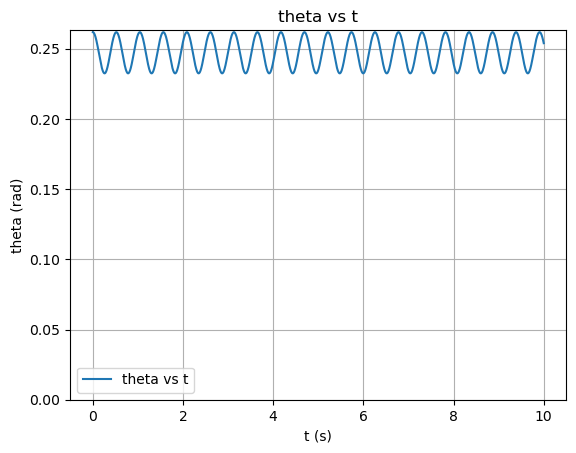

In [6]:
#theta vs t
plt.plot(t, solucion1.T[2], label="theta vs t")
plt.xlabel("t (s)")
plt.ylabel("theta (rad)")
plt.ylim(0)
plt.title("theta vs t")
dat=PosibleAjuste(solucion1, t)

#Amplitud positiva
a=float((max(solucion1.T[2])-min(solucion1.T[2]))/2)
b=float((max(solucion1.T[2])+min(solucion1.T[2]))/2)
#theta_f
f=b-a
print(f"theta_f: {f}")

plt.grid()
plt.legend(loc="best")
plt.show()

Frecuencia dominante: 1.9000000000000001
theta_f: 0.19467739651314217


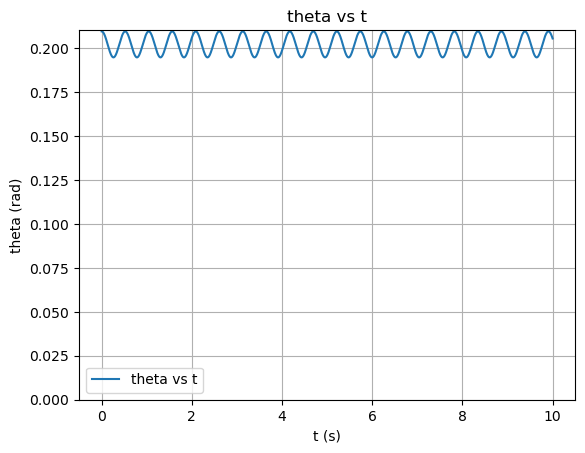

In [7]:
#theta vs t
plt.plot(t, solucion2.T[2], label="theta vs t")
plt.xlabel("t (s)")
plt.ylabel("theta (rad)")
plt.ylim(0)
plt.title("theta vs t")
dat=PosibleAjuste(solucion2, t)

#Amplitud positiva
a=float((max(solucion2.T[2])-min(solucion2.T[2]))/2)
b=float((max(solucion2.T[2])+min(solucion2.T[2]))/2)
#theta_f
f=b-a
print(f"theta_f: {f}")

plt.grid()
plt.legend(loc="best")
plt.show()

Frecuencia dominante: 1.9000000000000001
theta_f: 0.19324589690506158


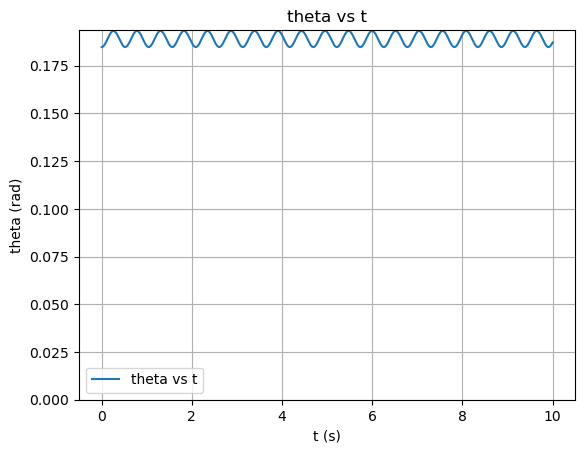

In [8]:
#theta vs t
plt.plot(t, solucion3.T[2], label="theta vs t")
plt.xlabel("t (s)")
plt.ylabel("theta (rad)")
plt.ylim(0)
plt.title("theta vs t")
dat=PosibleAjuste(solucion3, t)

#Amplitud negativa
a=float((min(solucion3.T[2])-max(solucion3.T[2]))/2)
b=float((min(solucion3.T[2])+max(solucion3.T[2]))/2)
#theta_f
f=b-a
print(f"theta_f: {f}")

plt.grid()
plt.legend(loc="best")
plt.show()

**Condiciones iniciales ángulo grande (comparativa de frecuencias)**

In [9]:
#Condiciones iniciales #1
theta_1=np.pi/4
phi_1=0
u_1=4.20
v_1=0

#Condiciones iniciales #2
theta_2=7*np.pi/18
phi_2=0
u_2=7.00
v_2=0

#Condiciones iniciales #3
theta_3=np.pi/12
phi_3=0
u_3=5.35
v_3=0

#S_0=(phi_0, u_0, theta_0, v_0)
S_1=(phi_1, u_1, theta_1, v_1)
S_2=(phi_2, u_2, theta_2, v_2)
S_3=(phi_3, u_3, theta_3, v_3)

#Intervalo de solución
t=np.linspace(0,5,5000)

In [10]:
#Se soluciona numéricamente el sistema de ecuaciones diferenciales (con las ecuaciones sin aproximar)
solucion1=odeint(ecuas2, y0=S_1, t=t, tfirst=True)
solucion2=odeint(ecuas2, y0=S_2, t=t, tfirst=True)
solucion3=odeint(ecuas2, y0=S_3, t=t, tfirst=True)

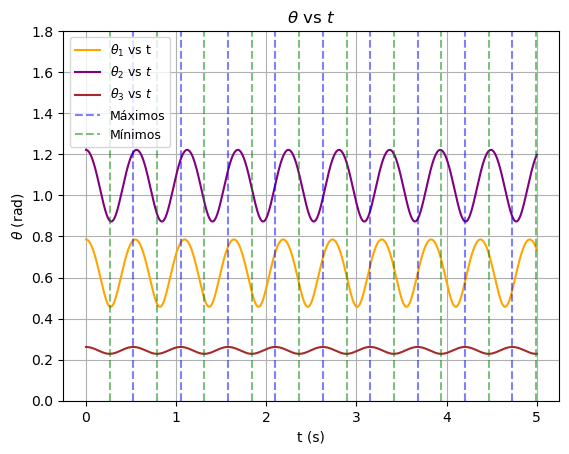

In [18]:
#theta vs t
plt.plot(t, solucion1.T[2], label=r"$\theta_1$ vs t", color="orange")
plt.plot(t, solucion2.T[2], label=r"$\theta_2$ vs $t$", color="purple")
plt.plot(t, solucion3.T[2], label=r"$\theta_3$ vs $t$", color="brown")

#Dibujo de líneas en picos de theta3
peaks, _ = find_peaks(solucion3.T[2])
valleys, _ = find_peaks(-solucion3.T[2])

for peak in peaks:
    plt.axvline(x=t[peak], color='blue', linestyle='--', alpha=0.5, label='Máximos' if peak == peaks[0] else "")

for valley in valleys:
    plt.axvline(x=t[valley], color='green', linestyle='--', alpha=0.5, label='Mínimos' if valley == valleys[0] else "")

plt.xlabel("t (s)")
plt.ylabel(r"$\theta$ (rad)")
plt.ylim(bottom=0, top=1.80)
plt.title(r"$\theta$ vs $t$")

plt.grid()
plt.legend(loc="best", fontsize=9)
plt.show()

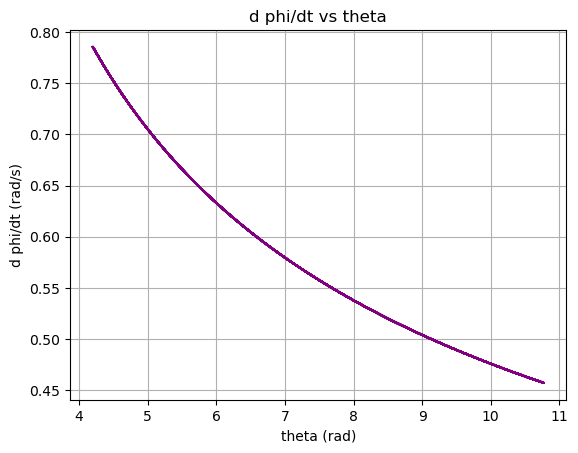

In [12]:
# Verificación de relación inverso cuadrado de phiPunto contra theta
plt.title("d phi/dt vs theta")
plt.plot(solucion1.T[1], solucion1.T[2], color="purple")
plt.xlabel("theta (rad)")
plt.ylabel("d phi/dt (rad/s)")

plt.grid()
plt.show()